# Notebook 06: Publisher Sales Performance

## Objective

This notebook examines whether certain video game publishers consistently produce higher-selling games and investigates the characteristics associated with their success.

Publisher performance is evaluated using several measures rather than total global sales alone. These measures include release volume, average and median sales per game, the proportion of games selling at least one million copies, sales consistency, regional sales, genre diversity, and platform diversity.

Using multiple measures helps distinguish publishers that accumulated high sales by releasing many games from publishers that produced fewer but more commercially successful titles.

The broader implications, limitations, connections to the other research questions, and final conclusions will be developed in the final project report.

## Research Question

**Do certain publishers consistently produce higher-selling games, and what characteristics might explain their success?**

## Unit of Analysis

Each row in the dataset represents a video game listed for a particular platform. A title released on multiple platforms may therefore appear more than once.

For simplicity, this notebook uses terms such as *game count*, *sales per game*, and *million-selling game rate*. These measures should be interpreted at the dataset-row level, meaning they reflect recorded game-platform releases rather than guaranteed unique game titles.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid", context="notebook")

In [4]:
candidate_paths = [
    Path("../../data/processed/video_game_sales_cleaned.csv"),
    Path("../data/processed/video_game_sales_cleaned.csv"),
    Path("data/processed/video_game_sales_cleaned.csv"),
]

data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        "Could not find video_game_sales_cleaned.csv. "
        "Update candidate_paths to match the notebook's location."
    )

df = pd.read_csv(data_path)

print(f"Loaded: {data_path.resolve()}")
print(f"Dataset shape: {df.shape}")
df.head()

Loaded: C:\Users\tyler\OneDrive\Desktop\26projects\data_an\data-analysis-on-the-videogame-industry\data\processed\video_game_sales_cleaned.csv
Dataset shape: (16287, 19)


,name,platform,year,genre,publisher,na_sales,eu_sales,jp_sales,other_sales,global_sales,regional_sales_total,decade,sales_tier,is_high_seller,na_sales_share,eu_sales_share,jp_sales_share,other_sales_share,dominant_region
0,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74,82.74,2000s,blockbuster,1,0.50,0.35,0.05,0.10,North America
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,40.24,1980s,blockbuster,1,0.72,0.09,0.17,0.02,North America
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82,35.83,2000s,blockbuster,1,0.44,0.36,0.11,0.09,North America
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00,33.00,2000s,blockbuster,1,0.48,0.33,0.10,0.09,North America
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,31.38,1990s,blockbuster,1,0.36,0.28,0.33,0.03,North America


In [5]:
required_columns = {
    "name", "publisher", "platform", "year", "genre",
    "na_sales", "eu_sales", "jp_sales", "other_sales", "global_sales",
}

missing_columns = required_columns.difference(df.columns)

if missing_columns:
    raise ValueError(
        f"The dataset is missing required columns: {sorted(missing_columns)}"
    )

df[list(required_columns)].info()

<class 'pandas.DataFrame'>
RangeIndex: 16287 entries, 0 to 16286
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   eu_sales      16287 non-null  float64
 1   publisher     16287 non-null  str    
 2   platform      16287 non-null  str    
 3   global_sales  16287 non-null  float64
 4   other_sales   16287 non-null  float64
 5   genre         16287 non-null  str    
 6   name          16287 non-null  str    
 7   year          16287 non-null  int64  
 8   na_sales      16287 non-null  float64
 9   jp_sales      16287 non-null  float64
dtypes: float64(5), int64(1), str(4)
memory usage: 1.2 MB


In [6]:
publisher_df = df.dropna(subset=["publisher", "global_sales"]).copy()
publisher_df["year"] = pd.to_numeric(publisher_df["year"], errors="coerce")

print(f"Rows used in this analysis: {len(publisher_df):,}")
print(f"Publishers represented: {publisher_df['publisher'].nunique():,}")
publisher_df.head()

Rows used in this analysis: 16,287
Publishers represented: 576


,name,platform,year,genre,publisher,na_sales,eu_sales,jp_sales,other_sales,global_sales,regional_sales_total,decade,sales_tier,is_high_seller,na_sales_share,eu_sales_share,jp_sales_share,other_sales_share,dominant_region
0,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74,82.74,2000s,blockbuster,1,0.50,0.35,0.05,0.10,North America
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,40.24,1980s,blockbuster,1,0.72,0.09,0.17,0.02,North America
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82,35.83,2000s,blockbuster,1,0.44,0.36,0.11,0.09,North America
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00,33.00,2000s,blockbuster,1,0.48,0.33,0.10,0.09,North America
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,31.38,1990s,blockbuster,1,0.36,0.28,0.33,0.03,North America


### Inspect Publisher Representation

Publishers differ substantially in the number of games represented in the dataset. Publishers with only one or two recorded games may have unusually high or low averages that do not reflect consistent performance.

Release counts are therefore examined before publisher rankings are calculated.

In [7]:
publisher_game_counts = (
    publisher_df.groupby("publisher", as_index=False)
                .agg(game_count=("name", "count"))
                .sort_values("game_count", ascending=False)
                .reset_index(drop=True)
)

publisher_game_counts.head(20)

,publisher,game_count
0,Electronic Arts,1339
1,Activision,966
2,Namco Bandai Games,928
3,Ubisoft,917
4,Konami Digital Entertainment,823
5,THQ,712
6,Nintendo,696
7,Sony Computer Entertainment,682
8,Sega,630
9,Take-Two Interactive,412


In [8]:
publisher_game_counts["game_count"].describe()

count     576.00
mean       28.28
std       115.38
min         1.00
25%         1.00
50%         3.00
75%        10.00
max     1,339.00
Name: game_count, dtype: float64

### Minimum Release Threshold

Average and median sales can be unstable for publishers represented by very few games. To focus on publishers with enough observations to evaluate consistency, the main comparative analysis includes publishers with at least **10 recorded games**.

Although the threshold reduces the influence of publishers represented by only a few releases, eligible publishers still have substantially different sample sizes. Rankings based on publishers close to the 10-release minimum should therefore be interpreted more cautiously than results based on several hundred releases.

This threshold is used only for publisher-level comparisons and does not remove records from the original dataset.

In [9]:
minimum_games = 10

eligible_publishers = publisher_game_counts.loc[
    publisher_game_counts["game_count"] >= minimum_games,
    "publisher"
].tolist()

publisher_analysis_df = publisher_df[
    publisher_df["publisher"].isin(eligible_publishers)
].copy()

print(f"Minimum games required: {minimum_games}")
print(f"Eligible publishers: {publisher_analysis_df['publisher'].nunique()}")
print(f"Games represented after threshold: {len(publisher_analysis_df):,}")

Minimum games required: 10
Eligible publishers: 152
Games represented after threshold: 15,146


In [10]:
publisher_summary = (
    publisher_analysis_df.groupby("publisher", as_index=False)
    .agg(
        game_count=("name", "count"),
        total_global_sales=("global_sales", "sum"),
        average_global_sales=("global_sales", "mean"),
        median_global_sales=("global_sales", "median"),
        sales_std=("global_sales", "std"),
        highest_game_sales=("global_sales", "max"),
        first_release_year=("year", "min"),
        last_release_year=("year", "max"),
        active_years=("year", "nunique"),
        platform_count=("platform", "nunique"),
        genre_count=("genre", "nunique"),
        na_sales=("na_sales", "sum"),
        eu_sales=("eu_sales", "sum"),
        jp_sales=("jp_sales", "sum"),
        other_sales=("other_sales", "sum"),
    )
)

publisher_summary.head()

,publisher,game_count,total_global_sales,average_global_sales,median_global_sales,sales_std,highest_game_sales,first_release_year,last_release_year,active_years,platform_count,genre_count,na_sales,eu_sales,jp_sales,other_sales
0,3DO,36,10.12,0.28,0.17,0.27,1.28,1998,2003,6,5,9,6.48,3.04,0.00,0.63
1,505 Games,192,55.91,0.29,0.11,0.75,6.81,2002,2016,15,13,12,31.83,16.43,2.05,5.44
2,5pb,61,1.63,0.03,0.02,0.02,0.11,2008,2016,9,8,6,0.02,0.00,1.61,0.00
3,989 Studios,14,13.32,0.95,0.69,0.69,2.31,1997,1999,3,1,3,9.23,3.30,0.10,0.67
4,ASCII Entertainment,20,10.89,0.54,0.35,0.52,2.09,1994,2001,7,6,7,0.70,0.44,9.40,0.36


In [11]:
publisher_summary["sales_coefficient_of_variation"] = (
    publisher_summary["sales_std"] / publisher_summary["average_global_sales"]
)

publisher_summary["recorded_year_span"] = (
    publisher_summary["last_release_year"]
    - publisher_summary["first_release_year"]
    + 1
)

publisher_summary["average_games_per_active_year"] = (
    publisher_summary["game_count"] / publisher_summary["active_years"]
)

In [12]:
regional_sales_columns = ["na_sales", "eu_sales", "jp_sales", "other_sales"]

for region in regional_sales_columns:
    publisher_summary[f"{region}_share_pct"] = (
        publisher_summary[region] / publisher_summary["total_global_sales"] * 100
    )

### High-Selling Game Rate

A publisher may accumulate high total sales through a few major hits or through many games with strong sales. To distinguish these patterns, the proportion of games selling at least one million copies is calculated for each publisher.

In [13]:
million_seller_summary = (
    publisher_analysis_df.assign(
        million_seller=publisher_analysis_df["global_sales"] >= 1.0
    )
    .groupby("publisher", as_index=False)
    .agg(
        million_selling_games=("million_seller", "sum"),
        million_seller_rate=("million_seller", "mean")
    )
)

million_seller_summary["million_seller_rate_pct"] = (
    million_seller_summary["million_seller_rate"] * 100
)

In [14]:
publisher_summary = publisher_summary.merge(
    million_seller_summary[
        ["publisher", "million_selling_games", "million_seller_rate_pct"]
    ],
    on="publisher",
    how="left"
)

### Publisher Genre Performance

In [15]:
publisher_genre_sales = (
    publisher_analysis_df.groupby(["publisher", "genre"], as_index=False)
    .agg(
        game_count=("name", "count"),
        global_sales=("global_sales", "sum"),
        average_game_sales=("global_sales", "mean")
    )
)

publisher_top_genre = (
    publisher_genre_sales.loc[
        publisher_genre_sales.groupby("publisher")["global_sales"].idxmax()
    ]
    .rename(columns={
        "genre": "top_genre",
        "game_count": "top_genre_game_count",
        "global_sales": "top_genre_sales",
        "average_game_sales": "top_genre_average_sales",
    })
    .reset_index(drop=True)
)

publisher_top_genre.head()

,publisher,top_genre,top_genre_game_count,top_genre_sales,top_genre_average_sales
0,3DO,Action,17,6.28,0.37
1,505 Games,Simulation,41,22.24,0.54
2,5pb,Adventure,49,1.34,0.03
3,989 Studios,Sports,9,8.97,1.00
4,ASCII Entertainment,Sports,8,7.08,0.89


In [16]:
publisher_summary = publisher_summary.merge(
    publisher_top_genre[[
        "publisher", "top_genre", "top_genre_game_count",
        "top_genre_sales", "top_genre_average_sales"
    ]],
    on="publisher",
    how="left"
)

### Publisher Platform Performance

In [17]:
publisher_platform_sales = (
    publisher_analysis_df.groupby(["publisher", "platform"], as_index=False)
    .agg(
        game_count=("name", "count"),
        global_sales=("global_sales", "sum"),
        average_game_sales=("global_sales", "mean")
    )
)

publisher_top_platform = (
    publisher_platform_sales.loc[
        publisher_platform_sales.groupby("publisher")["global_sales"].idxmax()
    ]
    .rename(columns={
        "platform": "top_platform",
        "game_count": "top_platform_game_count",
        "global_sales": "top_platform_sales",
        "average_game_sales": "top_platform_average_sales",
    })
    .reset_index(drop=True)
)

publisher_top_platform.head()

,publisher,top_platform,top_platform_game_count,top_platform_sales,top_platform_average_sales
0,3DO,PS,16,5.93,0.37
1,505 Games,DS,65,19.92,0.31
2,5pb,X360,15,0.44,0.03
3,989 Studios,PS,14,13.32,0.95
4,ASCII Entertainment,PS,8,5.50,0.69


In [18]:
publisher_summary = publisher_summary.merge(
    publisher_top_platform[[
        "publisher", "top_platform", "top_platform_game_count",
        "top_platform_sales", "top_platform_average_sales"
    ]],
    on="publisher",
    how="left"
)

publisher_summary = (
    publisher_summary.sort_values("total_global_sales", ascending=False)
    .reset_index(drop=True)
)

publisher_summary.head(15)

,publisher,game_count,total_global_sales,average_global_sales,median_global_sales,sales_std,highest_game_sales,first_release_year,last_release_year,active_years,platform_count,genre_count,na_sales,eu_sales,jp_sales,other_sales,sales_coefficient_of_variation,recorded_year_span,average_games_per_active_year,na_sales_share_pct,eu_sales_share_pct,jp_sales_share_pct,other_sales_share_pct,million_selling_games,million_seller_rate_pct,top_genre,top_genre_game_count,top_genre_sales,top_genre_average_sales,top_platform,top_platform_game_count,top_platform_sales,top_platform_average_sales
0,Nintendo,696,"1,784.43",2.56,0.92,5.68,82.74,1983,2016,34,10,12,815.75,418.30,454.99,95.19,2.21,34,20.47,45.71,23.44,25.50,5.33,338,48.56,Platform,111,426.18,3.84,Wii,81,390.34,4.82
1,Electronic Arts,1339,"1,093.39",0.82,0.47,1.06,8.49,1992,2016,24,19,12,584.22,367.38,13.98,127.63,1.30,25,55.79,53.43,33.60,1.28,11.67,337,25.17,Sports,554,468.69,0.85,PS2,196,245.96,1.25
2,Activision,966,721.41,0.75,0.28,1.64,14.76,1980,2016,32,20,12,426.01,213.72,6.54,74.79,2.20,37,30.19,59.05,29.63,0.91,10.37,159,16.46,Shooter,155,295.40,1.91,X360,133,158.75,1.19
3,Sony Computer Entertainment,682,607.28,0.89,0.34,1.56,14.98,1994,2016,23,6,12,265.22,187.55,74.10,80.40,1.75,23,29.65,43.67,30.88,12.20,13.24,149,21.85,Racing,65,110.57,1.70,PS,188,193.73,1.03
4,Ubisoft,917,473.25,0.52,0.21,0.94,10.26,1995,2016,22,19,12,252.54,163.03,7.33,50.14,1.82,22,41.68,53.36,34.45,1.55,10.59,117,12.76,Action,193,142.94,0.74,Wii,115,92.21,0.80
5,Take-Two Interactive,412,399.30,0.97,0.30,2.30,21.40,1997,2016,20,17,12,220.47,117.95,5.83,55.20,2.38,20,20.60,55.21,29.54,1.46,13.82,91,22.09,Action,93,211.08,2.27,X360,70,95.90,1.37
6,THQ,712,340.44,0.48,0.27,0.57,3.58,1995,2013,18,15,12,208.60,94.60,5.01,32.11,1.20,19,39.56,61.27,27.79,1.47,9.43,88,12.36,Action,193,89.16,0.46,PS2,100,75.37,0.75
7,Konami Digital Entertainment,823,278.56,0.34,0.15,0.63,6.05,1986,2016,30,23,12,88.91,68.62,90.93,29.91,1.85,31,27.43,31.92,24.63,32.64,10.74,61,7.41,Sports,279,98.15,0.35,PS2,161,81.86,0.51
8,Sega,630,270.66,0.43,0.19,0.72,8.06,1982,2016,28,21,12,108.78,81.41,56.15,24.30,1.67,35,22.50,40.19,30.08,20.75,8.98,74,11.75,Sports,134,71.69,0.54,Wii,42,40.56,0.97
9,Namco Bandai Games,928,253.65,0.27,0.12,0.46,4.24,1984,2016,33,23,12,69.38,42.61,126.84,14.64,1.67,33,28.12,27.35,16.80,50.01,5.77,53,5.71,Fighting,134,61.22,0.46,PS2,107,49.66,0.46


### 1. Publishers by Total Global Sales

Total global sales identify the publishers that accumulated the largest overall software-sales totals. This measure reflects both the commercial performance of individual games and the number of releases represented in the dataset.

In [19]:
top_publishers_total = publisher_summary.nlargest(10, "total_global_sales").copy()

top_publishers_total[[
    "publisher", "game_count", "total_global_sales",
    "average_global_sales", "median_global_sales"
]]

,publisher,game_count,total_global_sales,average_global_sales,median_global_sales
0,Nintendo,696,"1,784.43",2.56,0.92
1,Electronic Arts,1339,"1,093.39",0.82,0.47
2,Activision,966,721.41,0.75,0.28
3,Sony Computer Entertainment,682,607.28,0.89,0.34
4,Ubisoft,917,473.25,0.52,0.21
5,Take-Two Interactive,412,399.30,0.97,0.30
6,THQ,712,340.44,0.48,0.27
7,Konami Digital Entertainment,823,278.56,0.34,0.15
8,Sega,630,270.66,0.43,0.19
9,Namco Bandai Games,928,253.65,0.27,0.12


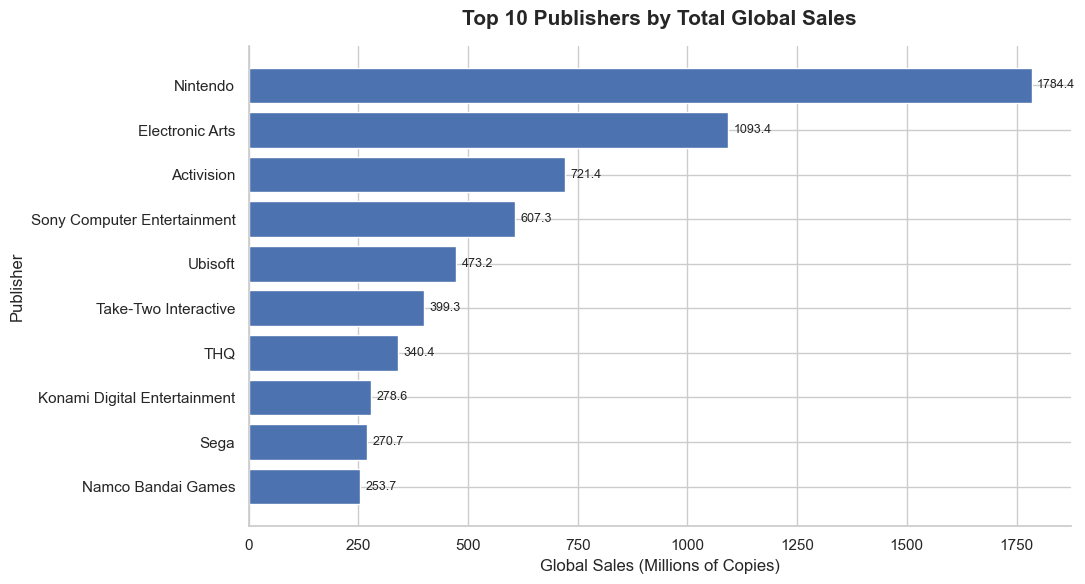

In [20]:
fig, ax = plt.subplots(figsize=(11, 6))
plot_data = top_publishers_total.sort_values("total_global_sales", ascending=True)
bars = ax.barh(plot_data["publisher"], plot_data["total_global_sales"])
ax.bar_label(bars, fmt="%.1f", padding=4, fontsize=9)
ax.set_title("Top 10 Publishers by Total Global Sales", fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Global Sales (Millions of Copies)")
ax.set_ylabel("Publisher")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

#### Key Takeaway

Nintendo was the clear leader in total global sales, reaching approximately **1,784.4 million copies**, well ahead of Electronic Arts at **1,093.4 million**. Activision ranked third with **721.4 million**, followed by Sony Computer Entertainment at **607.3 million**.

The large gap between Nintendo and the rest of the publishers suggests that its overall success came from a combination of a large catalog and strong-performing titles. However, total sales alone do not show whether Nintendo’s games sold more consistently on a per-game basis, so the average, median, and million-seller-rate comparisons are needed before judging publisher consistency.

### 2. Publishers by Average Sales per Game

Average sales per game reduce the influence of release volume and identify publishers whose games generated stronger sales on a per-title basis. Only publishers meeting the minimum release threshold are included.

In [21]:
top_publishers_average = publisher_summary.nlargest(10, "average_global_sales").copy()

top_publishers_average[[
    "publisher", "game_count", "average_global_sales",
    "median_global_sales", "highest_game_sales"
]]

,publisher,game_count,average_global_sales,median_global_sales,highest_game_sales
0,Nintendo,696,2.56,0.92,82.74
31,Sony Computer Entertainment Europe,15,1.59,1.00,5.99
10,Microsoft Game Studios,189,1.30,0.36,21.82
18,Bethesda Softworks,69,1.18,0.51,8.84
27,Enix Corporation,30,1.12,0.66,4.47
21,SquareSoft,52,1.11,0.69,7.86
5,Take-Two Interactive,412,0.97,0.30,21.40
17,LucasArts,89,0.95,0.52,5.83
42,989 Studios,14,0.95,0.69,2.31
39,Hasbro Interactive,16,0.95,0.56,4.16


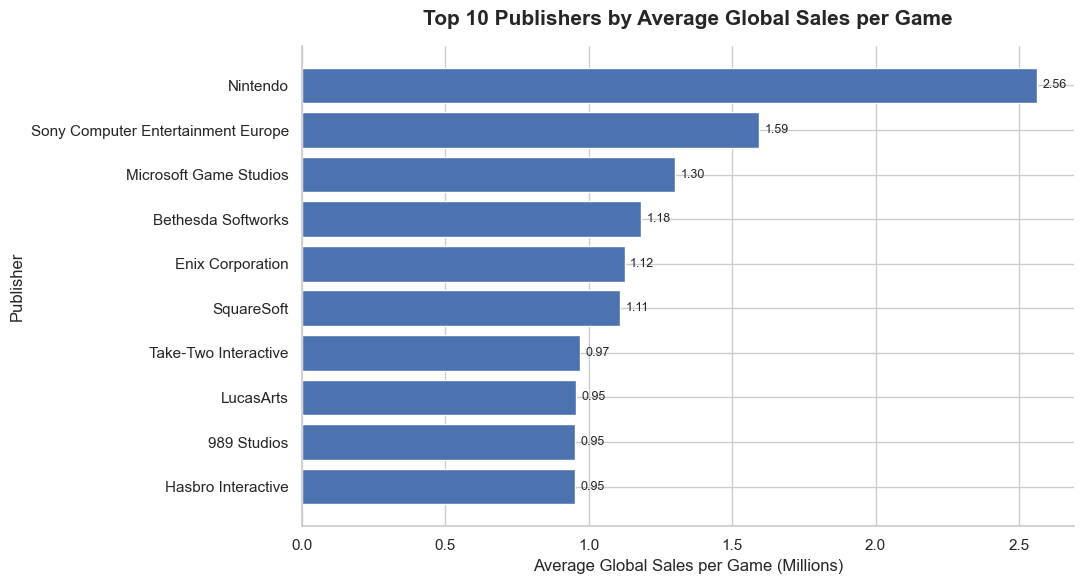

In [22]:
fig, ax = plt.subplots(figsize=(11, 6))
plot_data = top_publishers_average.sort_values("average_global_sales", ascending=True)
bars = ax.barh(plot_data["publisher"], plot_data["average_global_sales"])
ax.bar_label(bars, fmt="%.2f", padding=4, fontsize=9)
ax.set_title("Top 10 Publishers by Average Global Sales per Game", fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Average Global Sales per Game (Millions)")
ax.set_ylabel("Publisher")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

#### Key Takeaway

Nintendo also ranked first in average global sales per game, reaching approximately **2.56 million copies per title**. This was substantially higher than Sony Computer Entertainment Europe at **1.59 million** and Microsoft Game Studios at **1.30 million**.

Nintendo’s position at the top of both total sales and average sales per game suggests that its success was not driven only by a large number of releases. Its games also performed strongly on an individual-title basis. However, average sales can still be influenced by a small number of blockbuster games, so the median and million-seller-rate results are needed to judge how consistently this performance was achieved.

### 3. Publishers by Median Sales per Game

Game-sales distributions are usually right-skewed because a small number of blockbuster titles can raise a publisher's average substantially. Median sales provide a more resistant measure of the typical game.

In [23]:
top_publishers_median = publisher_summary.nlargest(10, "median_global_sales").copy()

top_publishers_median[[
    "publisher", "game_count", "median_global_sales",
    "average_global_sales", "million_seller_rate_pct"
]]

,publisher,game_count,median_global_sales,average_global_sales,million_seller_rate_pct
31,Sony Computer Entertainment Europe,15,1.00,1.59,53.33
0,Nintendo,696,0.92,2.56,48.56
21,SquareSoft,52,0.69,1.11,36.54
42,989 Studios,14,0.69,0.95,42.86
27,Enix Corporation,30,0.66,1.12,36.67
39,Hasbro Interactive,16,0.56,0.95,37.50
17,LucasArts,89,0.52,0.95,35.96
18,Bethesda Softworks,69,0.51,1.18,31.88
34,Universal Interactive,22,0.49,0.80,22.73
1,Electronic Arts,1339,0.47,0.82,25.17


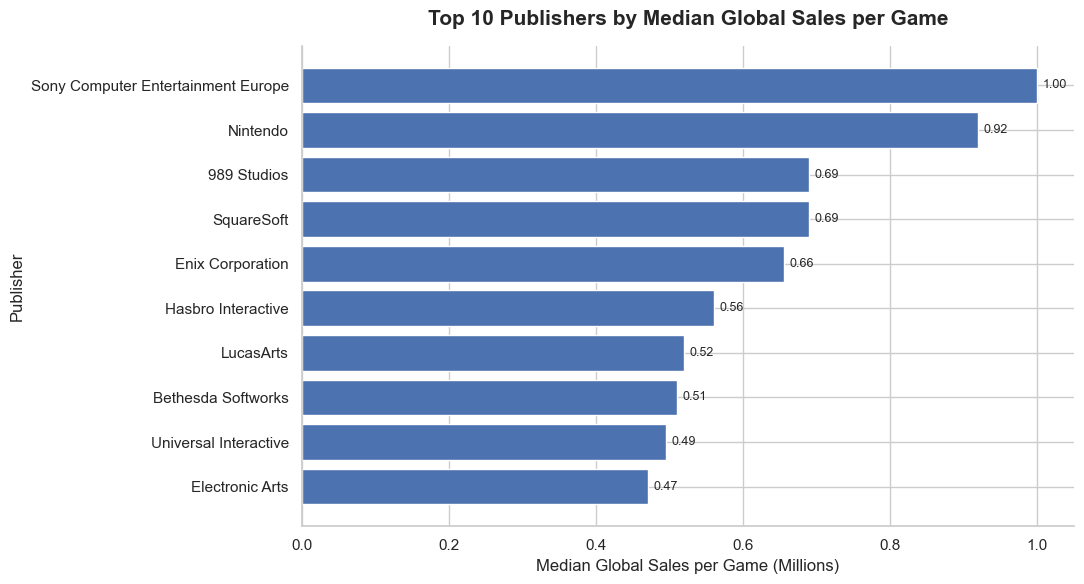

In [24]:
fig, ax = plt.subplots(figsize=(11, 6))
plot_data = top_publishers_median.sort_values("median_global_sales", ascending=True)
bars = ax.barh(plot_data["publisher"], plot_data["median_global_sales"])
ax.bar_label(bars, fmt="%.2f", padding=4, fontsize=9)
ax.set_title("Top 10 Publishers by Median Global Sales per Game", fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Median Global Sales per Game (Millions)")
ax.set_ylabel("Publisher")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

#### Key Takeaway

Sony Computer Entertainment Europe recorded the highest median global sales per game at **1.00 million copies**, meaning at least half of its titles reached approximately one million in global sales. Nintendo followed closely with a median of **0.92 million**.

Nintendo’s strong placement across total, average, and median sales suggests that its performance was not driven only by a few blockbuster releases. Sony Computer Entertainment Europe also showed strong typical-release performance, although its result is based on a much smaller number of recorded releases and should therefore be interpreted more cautiously than Nintendo’s.

### 4. Million-Selling Game Rate

The million-seller rate measures the percentage of each publisher's games that reached at least one million copies in global sales. This provides an intuitive measure of how regularly a publisher produced commercially successful titles.

In [25]:
top_publishers_million_rate = publisher_summary.nlargest(10, "million_seller_rate_pct").copy()

top_publishers_million_rate[[
    "publisher", "game_count", "million_selling_games",
    "million_seller_rate_pct", "average_global_sales"
]]

,publisher,game_count,million_selling_games,million_seller_rate_pct,average_global_sales
31,Sony Computer Entertainment Europe,15,8,53.33,1.59
0,Nintendo,696,338,48.56,2.56
42,989 Studios,14,6,42.86,0.95
39,Hasbro Interactive,16,6,37.50,0.95
27,Enix Corporation,30,11,36.67,1.12
21,SquareSoft,52,19,36.54,1.11
17,LucasArts,89,32,35.96,0.95
18,Bethesda Softworks,69,22,31.88,1.18
10,Microsoft Game Studios,189,54,28.57,1.30
1,Electronic Arts,1339,337,25.17,0.82


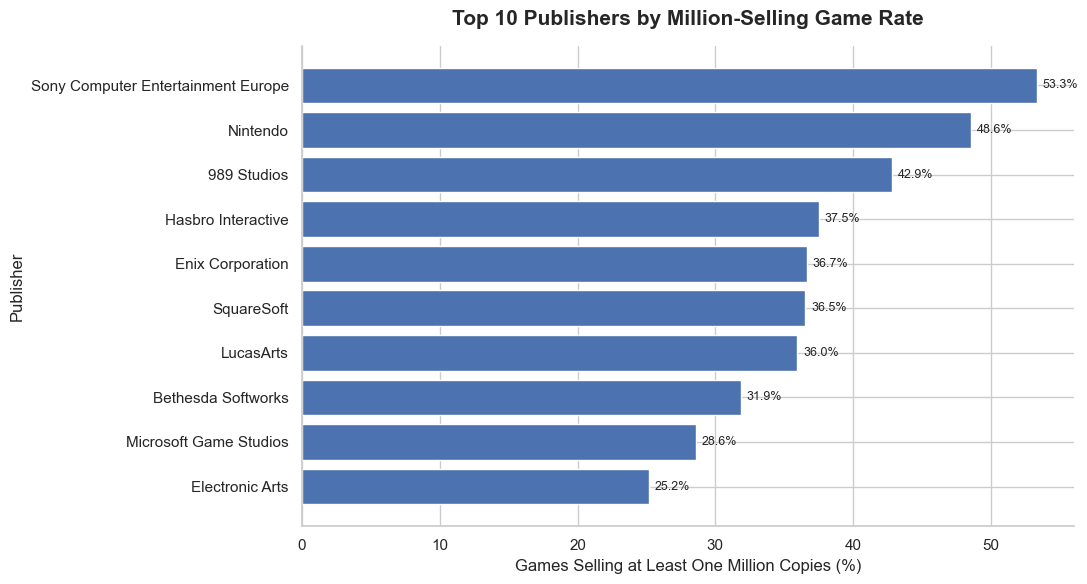

In [26]:
fig, ax = plt.subplots(figsize=(11, 6))
plot_data = top_publishers_million_rate.sort_values("million_seller_rate_pct", ascending=True)
bars = ax.barh(plot_data["publisher"], plot_data["million_seller_rate_pct"])
ax.bar_label(bars, fmt="%.1f%%", padding=4, fontsize=9)
ax.set_title("Top 10 Publishers by Million-Selling Game Rate", fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Games Selling at Least One Million Copies (%)")
ax.set_ylabel("Publisher")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

#### Key Takeaway

Sony Computer Entertainment Europe recorded the highest million-selling game rate, with approximately **53.3%** of its titles reaching at least one million copies in global sales. Nintendo followed closely at **48.6%**, while 989 Studios ranked third at **42.9%**.

These results show that Sony Computer Entertainment Europe and Nintendo had two of the highest proportions of million-selling releases among eligible publishers. However, Sony Computer Entertainment Europe’s rate is based on a much smaller catalog, while Nintendo maintained its high rate across several hundred recorded releases.

### 5. Relative Sales Consistency

The coefficient of variation compares each publisher's sales standard deviation with its average sales. Lower values indicate more stable game-level sales relative to the publisher's typical performance.

Because very low averages can produce misleading ratios, this comparison is limited to publishers whose average global sales are at least the median publisher average.

In [27]:
median_publisher_average = publisher_summary["average_global_sales"].median()

consistency_pool = publisher_summary[
    publisher_summary["average_global_sales"] >= median_publisher_average
].dropna(subset=["sales_coefficient_of_variation"]).copy()

most_consistent_publishers = consistency_pool.nsmallest(
    10, "sales_coefficient_of_variation"
).copy()

most_consistent_publishers[[
    "publisher", "game_count", "average_global_sales",
    "sales_std", "sales_coefficient_of_variation"
]]

,publisher,game_count,average_global_sales,sales_std,sales_coefficient_of_variation
85,Human Entertainment,13,0.23,0.12,0.53
80,Mattel Interactive,12,0.29,0.18,0.63
42,989 Studios,14,0.95,0.69,0.72
65,Ubisoft Annecy,14,0.32,0.25,0.78
87,Scholastic Inc.,10,0.29,0.23,0.80
82,Takara,16,0.22,0.18,0.82
114,Xplosiv,10,0.16,0.14,0.85
95,Imagineer,16,0.17,0.14,0.87
60,Tomy Corporation,18,0.28,0.25,0.89
94,Ghostlight,14,0.19,0.18,0.92


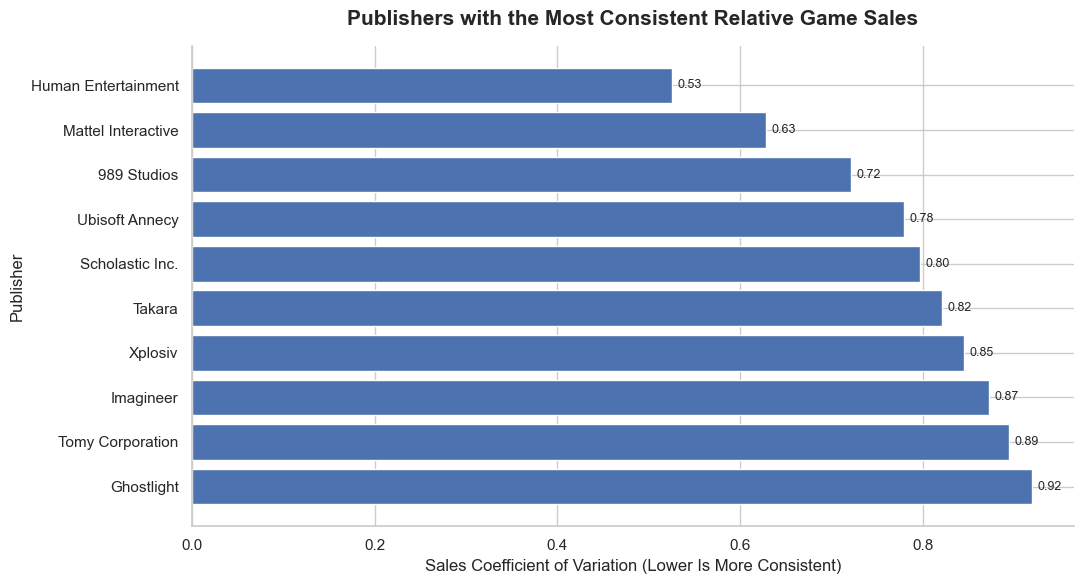

In [28]:
fig, ax = plt.subplots(figsize=(11, 6))
plot_data = most_consistent_publishers.sort_values(
    "sales_coefficient_of_variation", ascending=False
)
bars = ax.barh(
    plot_data["publisher"],
    plot_data["sales_coefficient_of_variation"]
)
ax.bar_label(bars, fmt="%.2f", padding=4, fontsize=9)
ax.set_title("Publishers with the Most Consistent Relative Game Sales", fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Sales Coefficient of Variation (Lower Is More Consistent)")
ax.set_ylabel("Publisher")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

#### Key Takeaway

Human Entertainment had the lowest sales coefficient of variation at **0.53**, indicating the most stable game-level sales relative to its average performance among the publishers included in this comparison. Mattel Interactive followed at **0.63**, while 989 Studios ranked third at **0.72**.

However, consistency does not necessarily mean stronger commercial performance. Several publishers in this chart were not among the leaders in total or average sales, which suggests that stable results can occur at more modest sales levels. Therefore, sales consistency should be interpreted together with average sales, median sales, and million-seller rate rather than as a standalone measure of publisher success.

Several of the highest-ranked publishers were also close to the 10-release eligibility threshold, so their consistency estimates are based on smaller samples than those of the major publishers.

### 6. Relationship Between Release Volume and Total Sales

Publishers with more releases have more opportunities to accumulate sales. Spearman correlation is used to measure the strength of the relationship between release count and total global sales without assuming a linear relationship.

A correlation heatmap displays the calculated coefficient, followed by a scatter plot showing the distribution of individual publishers. Both scatter-plot axes use logarithmic scales because publisher release counts and sales totals are highly uneven.

,game_count,total_global_sales
game_count,1.00,0.80
total_global_sales,0.80,1.00


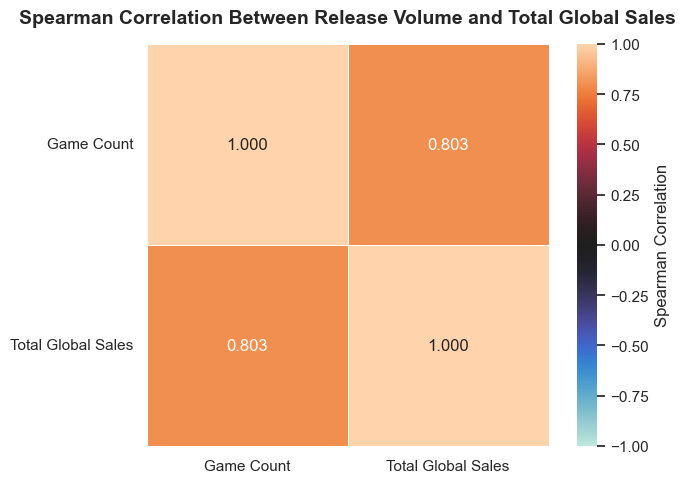

In [29]:
correlation_columns = [
    "game_count",
    "total_global_sales",
]

volume_sales_correlation_matrix = (
    publisher_summary[correlation_columns]
    .corr(method="spearman")
)

display(volume_sales_correlation_matrix)

fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(
    volume_sales_correlation_matrix,
    annot=True,
    fmt=".3f",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Spearman Correlation"},
    ax=ax,
)

ax.set_title(
    "Spearman Correlation Between Release Volume and Total Global Sales",
    fontsize=14,
    fontweight="bold",
    pad=15,
)

ax.set_xticklabels(
    ["Game Count", "Total Global Sales"],
    rotation=0,
)

ax.set_yticklabels(
    ["Game Count", "Total Global Sales"],
    rotation=0,
)

plt.tight_layout()
plt.show()

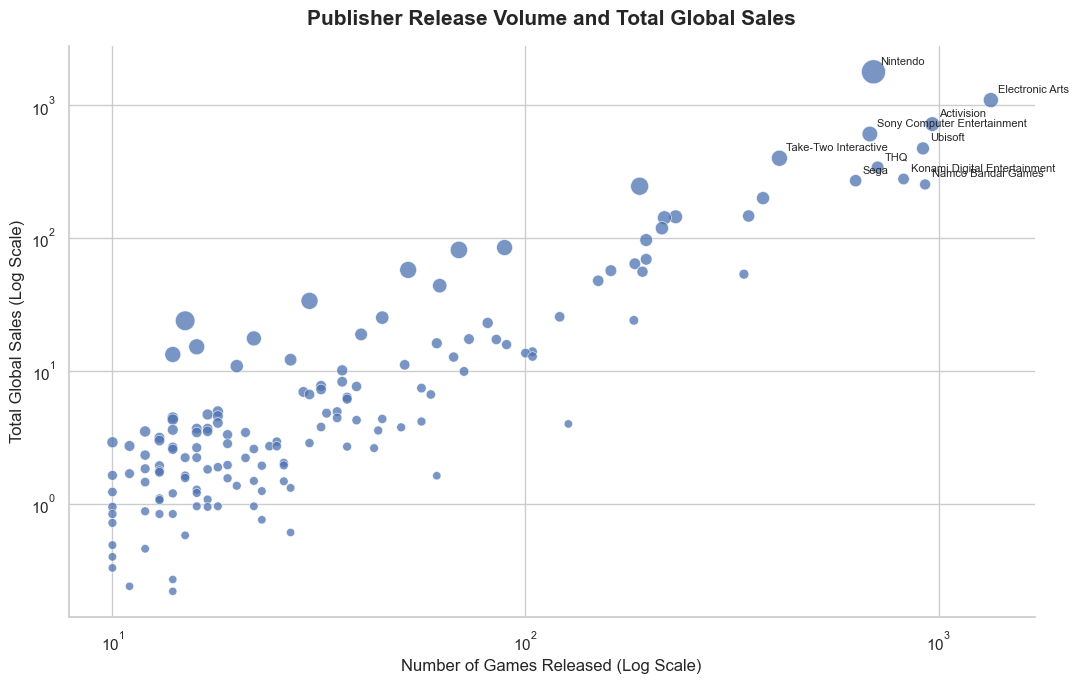

In [30]:
fig, ax = plt.subplots(figsize=(11, 7))

sns.scatterplot(
    data=publisher_summary,
    x="game_count",
    y="total_global_sales",
    size="average_global_sales",
    sizes=(35, 300),
    alpha=0.75,
    legend=False,
    ax=ax
)

top_label_publishers = publisher_summary.nlargest(10, "total_global_sales")

for _, row in top_label_publishers.iterrows():
    ax.annotate(
        row["publisher"],
        (row["game_count"], row["total_global_sales"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Publisher Release Volume and Total Global Sales", fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Number of Games Released (Log Scale)")
ax.set_ylabel("Total Global Sales (Log Scale)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

#### Key Takeaway

The scatter plot shows a strong positive relationship between publisher release volume and total global sales. The Spearman correlation was **0.803**, indicating that publishers with more recorded releases generally accumulated higher total sales.

However, the relationship was not perfectly proportional. Nintendo achieved the highest total sales despite releasing fewer games than Electronic Arts, suggesting that its advantage also came from stronger sales per title. Electronic Arts, Activision, Ubisoft, and several other major publishers combined large catalogs with high total sales, while Nintendo stood out for converting a comparatively smaller release volume into the strongest overall result.

Overall, publisher success appears to reflect both **how many games were released** and **how well those games performed individually**.

### 7. Regional Sales Profiles of Major Publishers

Regional sales shares show whether major publishers depended primarily on North America, Europe, Japan, or other markets. The comparison uses the ten publishers with the highest total global sales.

In [31]:
top_publishers_regional = (
    publisher_summary.nlargest(10, "total_global_sales")
    [[
        "publisher", "na_sales_share_pct", "eu_sales_share_pct",
        "jp_sales_share_pct", "other_sales_share_pct"
    ]]
    .set_index("publisher")
)

top_publishers_regional

,na_sales_share_pct,eu_sales_share_pct,jp_sales_share_pct,other_sales_share_pct
publisher,,,,
Nintendo,45.71,23.44,25.50,5.33
Electronic Arts,53.43,33.60,1.28,11.67
Activision,59.05,29.63,0.91,10.37
Sony Computer Entertainment,43.67,30.88,12.20,13.24
Ubisoft,53.36,34.45,1.55,10.59
Take-Two Interactive,55.21,29.54,1.46,13.82
THQ,61.27,27.79,1.47,9.43
Konami Digital Entertainment,31.92,24.63,32.64,10.74
Sega,40.19,30.08,20.75,8.98


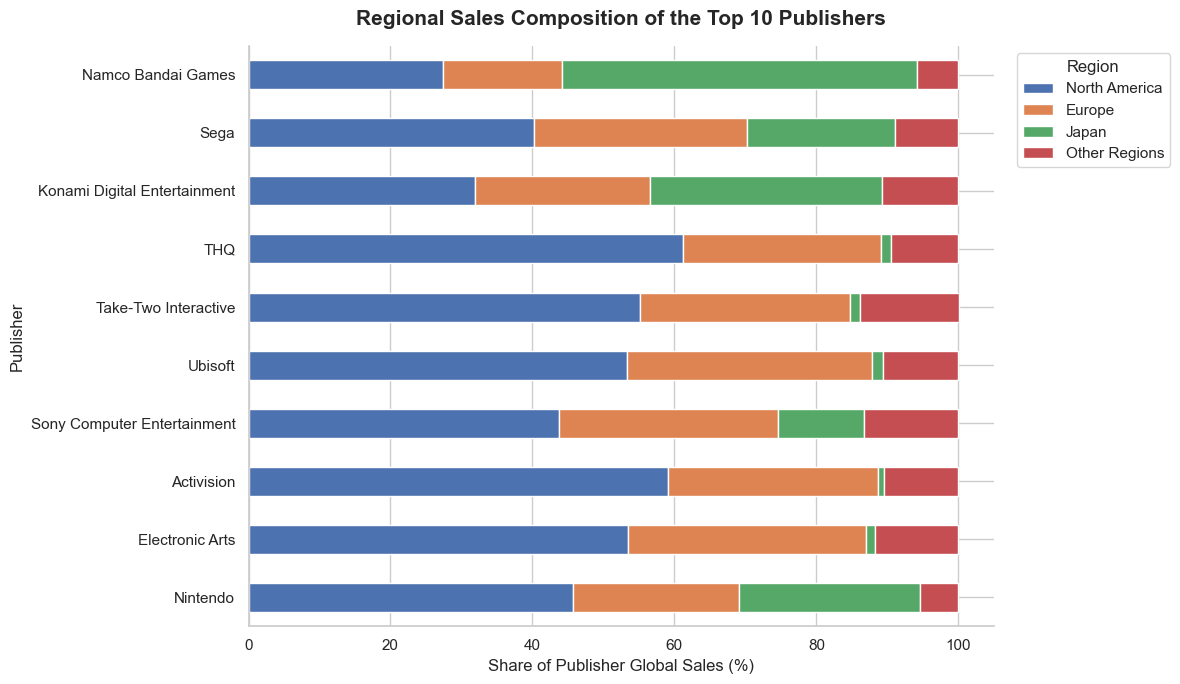

In [32]:
fig, ax = plt.subplots(figsize=(12, 7))

top_publishers_regional.plot(kind="barh", stacked=True, ax=ax)

ax.set_title("Regional Sales Composition of the Top 10 Publishers", fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Share of Publisher Global Sales (%)")
ax.set_ylabel("Publisher")
ax.legend(
    ["North America", "Europe", "Japan", "Other Regions"],
    title="Region",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

#### Key Takeaway

The top publishers followed noticeably different regional sales patterns. Electronic Arts, Activision, Ubisoft, THQ, and Take-Two Interactive generated most of their sales from **North America and Europe**, with only a very small share coming from Japan.

Nintendo had a more balanced regional profile, with substantial sales across **North America, Europe, and Japan**. Namco Bandai Games, Sega, and Konami Digital Entertainment were even more dependent on Japan than the other major publishers, with Japan accounting for a large portion of their global sales.

These differences suggest that publisher success was supported by different regional strategies. Some publishers relied primarily on Western markets, while Nintendo and several Japanese publishers benefited from stronger sales across Japan or a more diversified international audience.

### 8. Genre Concentration Among Major Publishers

A publisher's strongest genre may explain part of its sales performance. Genre concentration is measured as the percentage of a publisher's total global sales generated by its highest-selling genre.

Higher percentages indicate greater dependence on one genre, while lower percentages indicate a more diversified sales portfolio.

In [33]:
publisher_summary["top_genre_sales_share_pct"] = (
    publisher_summary["top_genre_sales"]
    / publisher_summary["total_global_sales"]
    * 100
)

top_publishers_genre = publisher_summary.nlargest(10, "total_global_sales")[[
    "publisher", "top_genre", "top_genre_sales",
    "top_genre_sales_share_pct", "genre_count"
]].copy()

top_publishers_genre

,publisher,top_genre,top_genre_sales,top_genre_sales_share_pct,genre_count
0,Nintendo,Platform,426.18,23.88,12
1,Electronic Arts,Sports,468.69,42.87,12
2,Activision,Shooter,295.40,40.95,12
3,Sony Computer Entertainment,Racing,110.57,18.21,12
4,Ubisoft,Action,142.94,30.20,12
5,Take-Two Interactive,Action,211.08,52.86,12
6,THQ,Action,89.16,26.19,12
7,Konami Digital Entertainment,Sports,98.15,35.23,12
8,Sega,Sports,71.69,26.49,12
9,Namco Bandai Games,Fighting,61.22,24.14,12


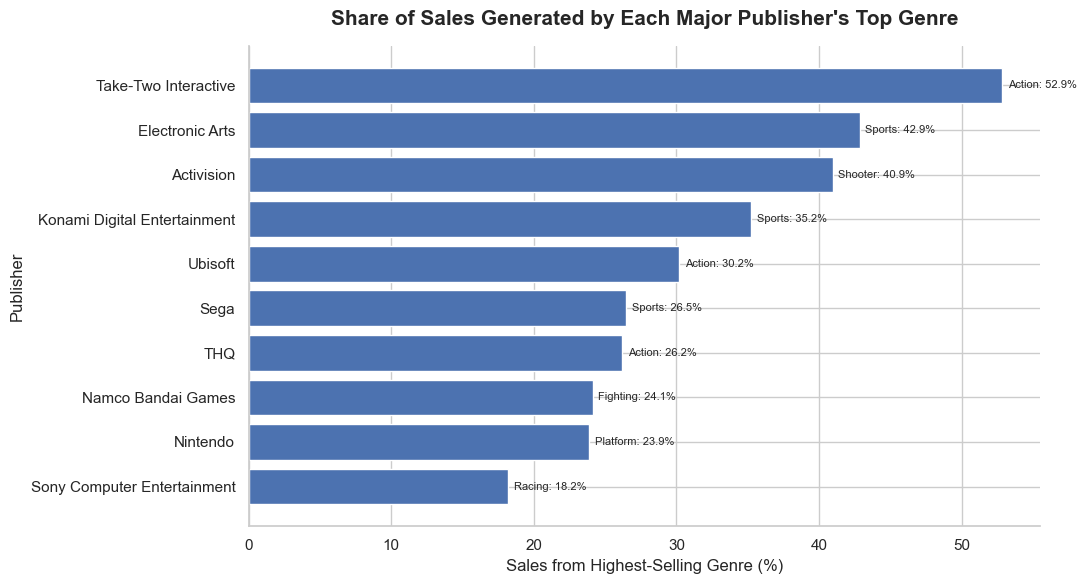

In [34]:
fig, ax = plt.subplots(figsize=(11, 6))
plot_data = top_publishers_genre.sort_values("top_genre_sales_share_pct", ascending=True)
bars = ax.barh(plot_data["publisher"], plot_data["top_genre_sales_share_pct"])
ax.bar_label(
    bars,
    labels=[
        f"{genre}: {share:.1f}%"
        for genre, share in zip(
            plot_data["top_genre"],
            plot_data["top_genre_sales_share_pct"]
        )
    ],
    padding=4,
    fontsize=8
)
ax.set_title("Share of Sales Generated by Each Major Publisher's Top Genre", fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Sales from Highest-Selling Genre (%)")
ax.set_ylabel("Publisher")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

#### Key Takeaway

Take-Two Interactive showed the greatest genre concentration, with **Action games accounting for 52.9%** of its total global sales. Electronic Arts and Activision were also strongly tied to a single genre, with **Sports contributing 42.9%** of Electronic Arts’ sales and **Shooters contributing 40.9%** of Activision’s.

Nintendo and Sony Computer Entertainment were much more diversified. Nintendo’s top genre, Platform, accounted for only **23.9%** of its sales, while Sony’s top genre, Racing, represented just **18.2%**. This suggests that some publishers achieved success through specialization in a dominant genre, while others, especially Nintendo and Sony, benefited from broader genre portfolios.

### 9. Platform Concentration Among Major Publishers

Platform concentration is measured as the percentage of a publisher's total global sales generated by its highest-selling platform.

This helps distinguish publishers whose success was spread across many systems from publishers whose sales were strongly tied to one platform.

In [35]:
publisher_summary["top_platform_sales_share_pct"] = (
    publisher_summary["top_platform_sales"]
    / publisher_summary["total_global_sales"]
    * 100
)

top_publishers_platform = publisher_summary.nlargest(10, "total_global_sales")[[
    "publisher", "top_platform", "top_platform_sales",
    "top_platform_sales_share_pct", "platform_count"
]].copy()

top_publishers_platform

,publisher,top_platform,top_platform_sales,top_platform_sales_share_pct,platform_count
0,Nintendo,Wii,390.34,21.87,10
1,Electronic Arts,PS2,245.96,22.50,19
2,Activision,X360,158.75,22.01,20
3,Sony Computer Entertainment,PS,193.73,31.90,6
4,Ubisoft,Wii,92.21,19.48,19
5,Take-Two Interactive,X360,95.90,24.02,17
6,THQ,PS2,75.37,22.14,15
7,Konami Digital Entertainment,PS2,81.86,29.39,23
8,Sega,Wii,40.56,14.99,21
9,Namco Bandai Games,PS2,49.66,19.58,23


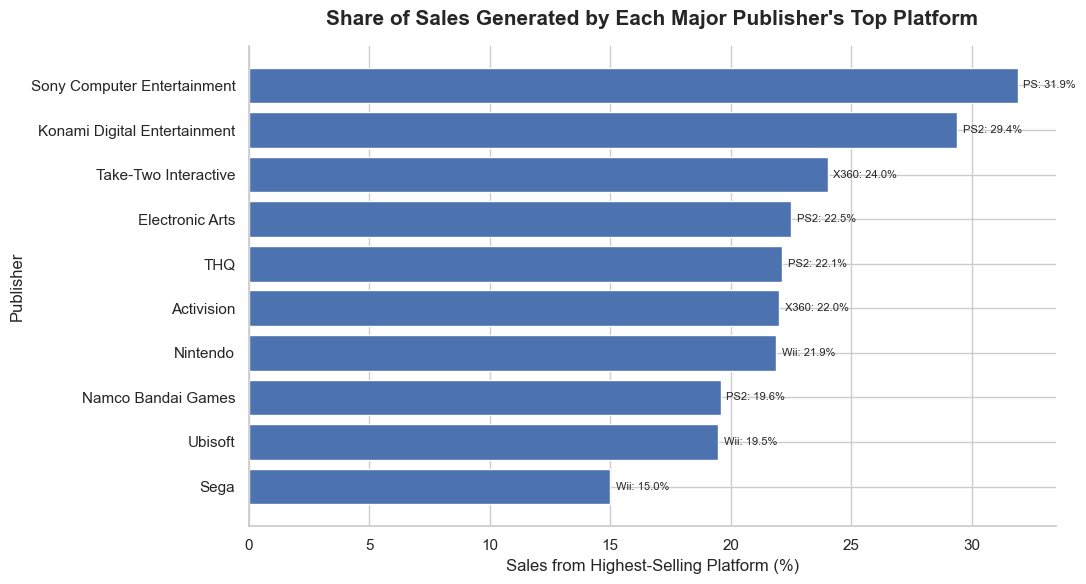

In [36]:
fig, ax = plt.subplots(figsize=(11, 6))
plot_data = top_publishers_platform.sort_values("top_platform_sales_share_pct", ascending=True)
bars = ax.barh(plot_data["publisher"], plot_data["top_platform_sales_share_pct"])
ax.bar_label(
    bars,
    labels=[
        f"{platform}: {share:.1f}%"
        for platform, share in zip(
            plot_data["top_platform"],
            plot_data["top_platform_sales_share_pct"]
        )
    ],
    padding=4,
    fontsize=8
)
ax.set_title("Share of Sales Generated by Each Major Publisher's Top Platform", fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Sales from Highest-Selling Platform (%)")
ax.set_ylabel("Publisher")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

#### Key Takeaway

Sony Computer Entertainment showed the greatest platform concentration among the major publishers, with the original PlayStation accounting for **31.9%** of its total global sales. Konami Digital Entertainment followed, with the PlayStation 2 generating **29.4%** of its sales.

Most of the other leading publishers were less dependent on a single platform. Their strongest systems generally contributed only about **15%–24%** of total sales, suggesting that their success was spread across several console generations. Nintendo, for example, generated its largest platform share from the Wii at **21.9%**, while Sega had the lowest concentration at **15.0%**.

Overall, the results suggest that platform diversification was common among the largest publishers, although Sony and Konami relied more heavily on one especially successful PlayStation platform.

### 10. Combined Publisher Performance Summary

The final table brings together the main performance and explanatory measures for the highest-selling publishers.

In [37]:
final_publisher_table = (
    publisher_summary.nlargest(15, "total_global_sales")
    [[
        "publisher", "game_count", "total_global_sales",
        "average_global_sales", "median_global_sales",
        "million_seller_rate_pct", "sales_coefficient_of_variation",
        "platform_count", "genre_count", "top_genre", "top_platform"
    ]]
    .rename(columns={
        "publisher": "Publisher",
        "game_count": "Games",
        "total_global_sales": "Total Global Sales",
        "average_global_sales": "Average Sales",
        "median_global_sales": "Median Sales",
        "million_seller_rate_pct": "Million-Seller Rate (%)",
        "sales_coefficient_of_variation": "Sales CV",
        "platform_count": "Platforms",
        "genre_count": "Genres",
        "top_genre": "Top Genre",
        "top_platform": "Top Platform",
    })
)

final_publisher_table

,Publisher,Games,Total Global Sales,Average Sales,Median Sales,Million-Seller Rate (%),Sales CV,Platforms,Genres,Top Genre,Top Platform
0,Nintendo,696,"1,784.43",2.56,0.92,48.56,2.21,10,12,Platform,Wii
1,Electronic Arts,1339,"1,093.39",0.82,0.47,25.17,1.30,19,12,Sports,PS2
2,Activision,966,721.41,0.75,0.28,16.46,2.20,20,12,Shooter,X360
3,Sony Computer Entertainment,682,607.28,0.89,0.34,21.85,1.75,6,12,Racing,PS
4,Ubisoft,917,473.25,0.52,0.21,12.76,1.82,19,12,Action,Wii
5,Take-Two Interactive,412,399.30,0.97,0.30,22.09,2.38,17,12,Action,X360
6,THQ,712,340.44,0.48,0.27,12.36,1.20,15,12,Action,PS2
7,Konami Digital Entertainment,823,278.56,0.34,0.15,7.41,1.85,23,12,Sports,PS2
8,Sega,630,270.66,0.43,0.19,11.75,1.67,21,12,Sports,Wii
9,Namco Bandai Games,928,253.65,0.27,0.12,5.71,1.67,23,12,Fighting,PS2


## Overall Interpretation

The results show that certain publishers did consistently produce higher-selling games, but publisher success was usually explained by a combination of factors rather than one measure alone.

Nintendo was the strongest overall publisher in the dataset. It ranked first in total global sales at approximately **1,784.4 million copies** and also had the highest average sales per game at about **2.56 million copies**. Its median sales of **0.92 million copies** and million-seller rate of **48.6%** also show that this performance was not driven only by a small number of blockbuster titles. A large share of Nintendo’s catalog performed strongly, making it the clearest example of a publisher that combined high total sales with strong typical game performance.

Sony Computer Entertainment Europe also showed strong game-level performance. It had the highest median sales per recorded release at **1.00 million copies** and the highest million-seller rate at **53.3%**. However, these results are based on a much smaller number of recorded releases than Nintendo’s results and should therefore be interpreted more cautiously. Within its represented catalog, a typical release still had a comparatively strong chance of reaching a high sales level.

Release volume was also an important contributor to publisher success. The scatter plot showed a strong positive relationship between the number of games released and total global sales. Publishers such as Electronic Arts, Activision, Ubisoft, and THQ accumulated large sales totals partly through extensive catalogs. However, Nintendo achieved the highest total sales despite releasing fewer games than Electronic Arts, showing that release volume alone was not enough. Stronger sales per title were also necessary to explain its lead.

The consistency analysis provided a different perspective. Human Entertainment, Mattel Interactive, and 989 Studios had the lowest coefficients of variation, meaning their sales were relatively stable around their own averages. However, most were not among the strongest publishers in total or average sales. This shows that consistency by itself does not necessarily mean high commercial performance. A publisher can produce stable results at a relatively modest sales level.

Regional strength also differed across publishers. Electronic Arts, Activision, Ubisoft, THQ, and Take-Two Interactive depended primarily on North American and European markets. Nintendo had a more balanced international profile, with substantial sales in North America, Europe, and Japan. Namco Bandai Games, Sega, and Konami Digital Entertainment relied more heavily on Japan. This suggests that some publishers succeeded through broad international appeal, while others were more closely tied to specific regional markets.

Genre strategy also varied. Take-Two Interactive, Electronic Arts, and Activision were strongly associated with one leading genre, with Action, Sports, and Shooter games accounting for large shares of their sales. Nintendo and Sony Computer Entertainment were more diversified across genres. Therefore, publisher success could come either from specialization in a commercially strong genre or from a broader portfolio that reduced dependence on one category.

Platform concentration was generally moderate among the major publishers. Sony Computer Entertainment and Konami Digital Entertainment were the most dependent on one leading platform, while Nintendo, Sega, Ubisoft, and several others spread their sales across multiple systems. This suggests that long-term publisher performance was usually supported by participation across several console generations rather than complete reliance on one platform.

Overall, the evidence shows that publisher success was associated with a combination of **release volume, strong typical game performance, a high rate of million-selling titles, regional reach, and effective genre and platform strategies**. Nintendo was the strongest all-around publisher because it performed well across nearly every measure. Other publishers succeeded through different models: some relied on large catalogs, some specialized in particular genres or regions, and some produced fewer but more consistently successful games.